In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [3]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [4]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [5]:
# Per la matrice di correlazione :
jet_features = ['logpt', 'eta', 'phi', 'mass']

met_features = [
    'MET_logpt', 'MET_phi', 'MET_covXX', 'MET_covXY',
    'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered'
]

df["jet1_logpt"] = jets[:,0,0]
df["jet1_eta"]   = jets[:,0,1]
df["jet1_phi"]   = jets[:,0,2]
df["jet1_mass"]  = jets[:,0,3]

df["jet2_logpt"] = jets[:,1,0]
df["jet2_eta"]   = jets[:,1,1]
df["jet2_phi"]   = jets[:,1,2]
df["jet2_mass"]  = jets[:,1,3]

df["jet3_logpt"] = jets[:,2,0]
df["jet3_eta"]   = jets[:,2,1]
df["jet3_phi"]   = jets[:,2,2]
df["jet3_mass"]  = jets[:,2,3]


met_features = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

for i, name in enumerate(met_features):
    df[name] = met[:,0,i]




df_H["jet1_logpt"] = jets_H[:,0,0]
df_H["jet1_eta"]   = jets_H[:,0,1]
df_H["jet1_phi"]   = jets_H[:,0,2]
df_H["jet1_mass"]  = jets_H[:,0,3]

df_H["jet2_logpt"] = jets_H[:,1,0]
df_H["jet2_eta"]   = jets_H[:,1,1]
df_H["jet2_phi"]   = jets_H[:,1,2]
df_H["jet2_mass"]  = jets_H[:,1,3]

df_H["jet3_logpt"] = jets_H[:,2,0]
df_H["jet3_eta"]   = jets_H[:,2,1]
df_H["jet3_phi"]   = jets_H[:,2,2]
df_H["jet3_mass"]  = jets_H[:,2,3]


for i, name in enumerate(met_features):
    df_H[name] = met_H[:,0,i]

In [6]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [7]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [8]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [9]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [10]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [11]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [12]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [13]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [14]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [15]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [16]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [17]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [18]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [19]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [20]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [21]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


In [22]:
# Sistemo i nomi delle colonne sbagliate :
# ========= DY =========
df_DY_event = df_DY_event.copy()

# reco
df_DY_event["tau1_pt_reco"] = np.exp(df_DY_event["tau1_logpt"])
df_DY_event["tau2_pt_reco"] = np.exp(df_DY_event["tau2_logpt"])

# gen 
df_DY_event["tau1_pt_gen"] = df_DY_event["gen_tau1_logpt"]
df_DY_event["tau2_pt_gen"] = df_DY_event["gen_tau2_logpt"]

# ========= Higgs =========
df_H_event = df_H_event.copy()

df_H_event["tau1_pt_reco"] = np.exp(df_H_event["tau1_logpt"])
df_H_event["tau2_pt_reco"] = np.exp(df_H_event["tau2_logpt"])

df_H_event["tau1_pt_gen"] = df_H_event["gen_tau1_logpt"]
df_H_event["tau2_pt_gen"] = df_H_event["gen_tau2_logpt"]


# Model

### FASE 1 - Costruzione del modello:
    - CouplingMLP
    - ConditionalAffineCoupling
    - ConditionalRealNVP
    - build_flow()

### FASE 2 - Training del flow

### FASE 3 - Inferenza fisica

In [23]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [24]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [25]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [27]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


## Modello

In [34]:
'''''''''
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from scipy.stats import entropy

# --- 1. PREPARAZIONE DATASET E SPLIT ---
# Unisco i due campioni per lo split, mantenendo le label
df_all = pd.concat([df_DY_event, df_H_event], ignore_index=True)

# Divisione 80% Train, 10% Validation, 10% Test
df_train, df_temp = train_test_split(df_all, test_size=0.20, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)

# --- 2. SCALING (FIT SOLO SU TRAIN) ---
class TorchStandardScaler:
    def fit(self, x):
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, keepdim=True)
    def transform(self, x):
        return (x - self.mean) / (self.std + 1e-8)
    def inverse_transform(self, x):
        return x * self.std + self.mean

# Trasformazione in tensori
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_raw = torch.tensor(df_train[train_cols].values, dtype=torch.float32).to(device)
y_train_raw = torch.tensor(df_train[y_cols].values, dtype=torch.float32).to(device)

X_val_raw = torch.tensor(df_val[train_cols].values, dtype=torch.float32).to(device)
y_val_raw = torch.tensor(df_val[y_cols].values, dtype=torch.float32).to(device)

# Fit dello scaler SOLO sui dati di training
scaler_X = TorchStandardScaler()
scaler_y = TorchStandardScaler()
scaler_X.fit(X_train_raw)
scaler_y.fit(y_train_raw)

# DataLoader per Train e Validation (Standardizzati)
train_dataset = TensorDataset(scaler_X.transform(X_train_raw), scaler_y.transform(y_train_raw))
val_dataset = TensorDataset(scaler_X.transform(X_val_raw), scaler_y.transform(y_val_raw))

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

# --- 3. DEFINIZIONE MODELLO E TRAINING ---
class PTCorrectionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

model = PTCorrectionNet(len(train_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss() # MAE

epochs = 60
history = {'train': [], 'val': []}

for epoch in range(epochs):
    model.train()
    t_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            v_loss += criterion(model(bx), by).item()
    
    history['train'].append(t_loss/len(train_loader))
    history['val'].append(v_loss/len(val_loader))
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Train MAE: {history['train'][-1]:.4f} | Val MAE: {history['val'][-1]:.4f}")

# --- 4. VALUTAZIONE FINALE SUL TEST SET  ---
def evaluate_on_test(df_test_sample):
    model.eval()
    with torch.no_grad():
        X_test = torch.tensor(df_test_sample[train_cols].values, dtype=torch.float32).to(device)
        y_pred_scaled = model(scaler_X.transform(X_test))
        y_pred = scaler_y.inverse_transform(y_pred_scaled).cpu().numpy()
    
    # Ricalcolo Masse Invarianti
    pt1_p = df_test_sample["tau1_pt_reco"].values * y_pred[:, 0]
    pt2_p = df_test_sample["tau2_pt_reco"].values * y_pred[:, 1]
    
    # (Funzione massa vettorizzata)
    def calc_m(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
        px1, py1, pz1 = pt1*np.cos(phi1), pt1*np.sin(phi1), pt1*np.sinh(eta1)
        e1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)
        px2, py2, pz2 = pt2*np.cos(phi2), pt2*np.sin(phi2), pt2*np.sinh(eta2)
        e2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)
        return np.sqrt((e1+e2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2)

    m_inv = calc_m(pt1_p, df_test_sample.tau1_eta, df_test_sample.tau1_phi, df_test_sample.tau1_mass,
                   pt2_p, df_test_sample.tau2_eta, df_test_sample.tau2_phi, df_test_sample.tau2_mass)
    return m_inv, y_pred

# Separazione Higgs e DY all'interno del Test Set
df_test_H = df_test[df_test['class'] == 1]
df_test_DY = df_test[df_test['class'] == 0]

m_inv_H_test, y_pred_H = evaluate_on_test(df_test_H)
m_inv_DY_test, y_pred_DY = evaluate_on_test(df_test_DY)

# --- METRICHE FINALI ---
bins = np.linspace(0, 300, 100)
p, _ = np.histogram(m_inv_H_test, bins=bins, density=True)
q, _ = np.histogram(m_inv_DY_test, bins=bins, density=True)
kl_final = entropy(p + 1e-10, q + 1e-10)

s_peak = np.sum((m_inv_H_test > 110) & (m_inv_H_test < 140))
b_peak = np.sum((m_inv_DY_test > 110) & (m_inv_DY_test < 140))

print("\n--- RISULTATI TEST SET (80/10/10 Split) ---")
print(f"KL Divergence: {kl_final:.4f}")
print(f"S/B (110-140 GeV): {s_peak/(b_peak + 1e-10):.4f}")
print(f"MAE Correzioni Test (H): {np.mean(np.abs(y_pred_H - df_test_H[y_cols].values)):.4f}")

Epoch 00 | Train MAE: 0.5901 | Val MAE: 0.5674
Epoch 10 | Train MAE: 0.4733 | Val MAE: 0.4894
Epoch 20 | Train MAE: 0.4521 | Val MAE: 0.4886
Epoch 30 | Train MAE: 0.4373 | Val MAE: 0.4928
Epoch 40 | Train MAE: 0.4251 | Val MAE: 0.4929
Epoch 50 | Train MAE: 0.4153 | Val MAE: 0.4951

--- RISULTATI TEST SET (80/10/10 Split) ---
KL Divergence: 0.8575
S/B (110-140 GeV): 7.2479
MAE Correzioni Test (H): 0.1755


In [54]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from scipy.stats import entropy
import copy

# --- 1. PREPARAZIONE DATASET E SPLIT ---
df_all = pd.concat([df_DY_event, df_H_event], ignore_index=True)
df_train, df_temp = train_test_split(df_all, test_size=0.20, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)

# --- 2. SCALING ---
class TorchStandardScaler:
    def fit(self, x):
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, keepdim=True)
    def transform(self, x):
        return (x - self.mean) / (self.std + 1e-8)
    def inverse_transform(self, x):
        return x * self.std + self.mean

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_raw = torch.tensor(df_train[train_cols].values, dtype=torch.float32).to(device)
y_train_raw = torch.tensor(df_train[y_cols].values, dtype=torch.float32).to(device)
X_val_raw = torch.tensor(df_val[train_cols].values, dtype=torch.float32).to(device)
y_val_raw = torch.tensor(df_val[y_cols].values, dtype=torch.float32).to(device)

scaler_X = TorchStandardScaler()
scaler_y = TorchStandardScaler()
scaler_X.fit(X_train_raw)
scaler_y.fit(y_train_raw)

train_loader = DataLoader(TensorDataset(scaler_X.transform(X_train_raw), scaler_y.transform(y_train_raw)), batch_size=1024, shuffle=True)
val_loader = DataLoader(TensorDataset(scaler_X.transform(X_val_raw), scaler_y.transform(y_val_raw)), batch_size=1024, shuffle=False)

# --- 3. MODELLO E TRAINING CON EARLY STOPPING ---
model = PTCorrectionNet(len(train_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss()

epochs = 200
patience = 15  
best_val_loss = float('inf')
counter = 0
best_model_state = None

history = {'train': [], 'val': []}

print("Inizio Training:")
for epoch in range(epochs):
    model.train()
    t_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            v_loss += criterion(model(bx), by).item()
    
    avg_train_loss = t_loss / len(train_loader)
    avg_val_loss = v_loss / len(val_loader)
    history['train'].append(avg_train_loss)
    history['val'].append(avg_val_loss)
    
    # Logica Early Stopping corretta
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict()) 
        counter = 0
    else:
        counter += 1
        
    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | Best: {best_val_loss:.4f}")
    
    if counter >= patience:
        print(f"Early stopping all'epoca {epoch}. Ripristino del modello migliore.")
        break

# Caricamento del miglior stato trovato
if best_model_state:
    model.load_state_dict(best_model_state)

# --- 4. VALUTAZIONE SUL TEST SET ---
def evaluate_on_test(df_test_sample):
    model.eval()
    with torch.no_grad():
        X_test = torch.tensor(df_test_sample[train_cols].values, dtype=torch.float32).to(device)
        y_pred_scaled = model(scaler_X.transform(X_test))
        y_pred = scaler_y.inverse_transform(y_pred_scaled).cpu().numpy()
    
    pt1_p = df_test_sample["tau1_pt_reco"].values * y_pred[:, 0]
    pt2_p = df_test_sample["tau2_pt_reco"].values * y_pred[:, 1]
    
    def calc_m(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
        px1, py1, pz1 = pt1*np.cos(phi1), pt1*np.sin(phi1), pt1*np.sinh(eta1)
        e1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)
        px2, py2, pz2 = pt2*np.cos(phi2), pt2*np.sin(phi2), pt2*np.sinh(eta2)
        e2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)
        return np.sqrt(np.maximum((e1+e2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2, 0))

    m_inv = calc_m(pt1_p, df_test_sample.tau1_eta, df_test_sample.phi1 if 'phi1' in df_test_sample else df_test_sample.tau1_phi, df_test_sample.tau1_mass,
                   pt2_p, df_test_sample.tau2_eta, df_test_sample.phi2 if 'phi2' in df_test_sample else df_test_sample.tau2_phi, df_test_sample.tau2_mass)
    return m_inv, y_pred

df_test_H = df_test[df_test['class'] == 1]
df_test_DY = df_test[df_test['class'] == 0]
m_inv_H_test, y_pred_H = evaluate_on_test(df_test_H)
m_inv_DY_test, y_pred_DY = evaluate_on_test(df_test_DY)

# --- CALCOLO METRICHE FINALI ---
bins = np.linspace(0, 300, 100)
p, _ = np.histogram(m_inv_H_test, bins=bins, density=True)
q, _ = np.histogram(m_inv_DY_test, bins=bins, density=True)
kl_final = entropy(p + 1e-10, q + 1e-10)
s_peak = np.sum((m_inv_H_test > 110) & (m_inv_H_test < 140))
b_peak = np.sum((m_inv_DY_test > 110) & (m_inv_DY_test < 140))

print("\n--- RISULTATI TEST SET (Best Model) ---")
print(f"KL Divergence: {kl_final:.4f} | S/B (110-140): {s_peak/(b_peak + 1e-10):.4f}")

Inizio Training:
Epoch 000 | Train: 0.5854 | Val: 0.5663 | Best: 0.5663
Epoch 005 | Train: 0.4936 | Val: 0.4984 | Best: 0.4984
Epoch 010 | Train: 0.4723 | Val: 0.4870 | Best: 0.4870
Epoch 015 | Train: 0.4605 | Val: 0.4865 | Best: 0.4862
Epoch 020 | Train: 0.4509 | Val: 0.4880 | Best: 0.4862
Epoch 025 | Train: 0.4430 | Val: 0.4898 | Best: 0.4859
Epoch 030 | Train: 0.4362 | Val: 0.4925 | Best: 0.4859
Epoch 035 | Train: 0.4306 | Val: 0.4910 | Best: 0.4859
Early stopping all'epoca 37. Ripristino del modello migliore.

--- RISULTATI TEST SET (Best Model) ---
KL Divergence: 0.9766 | S/B (110-140): 8.3325


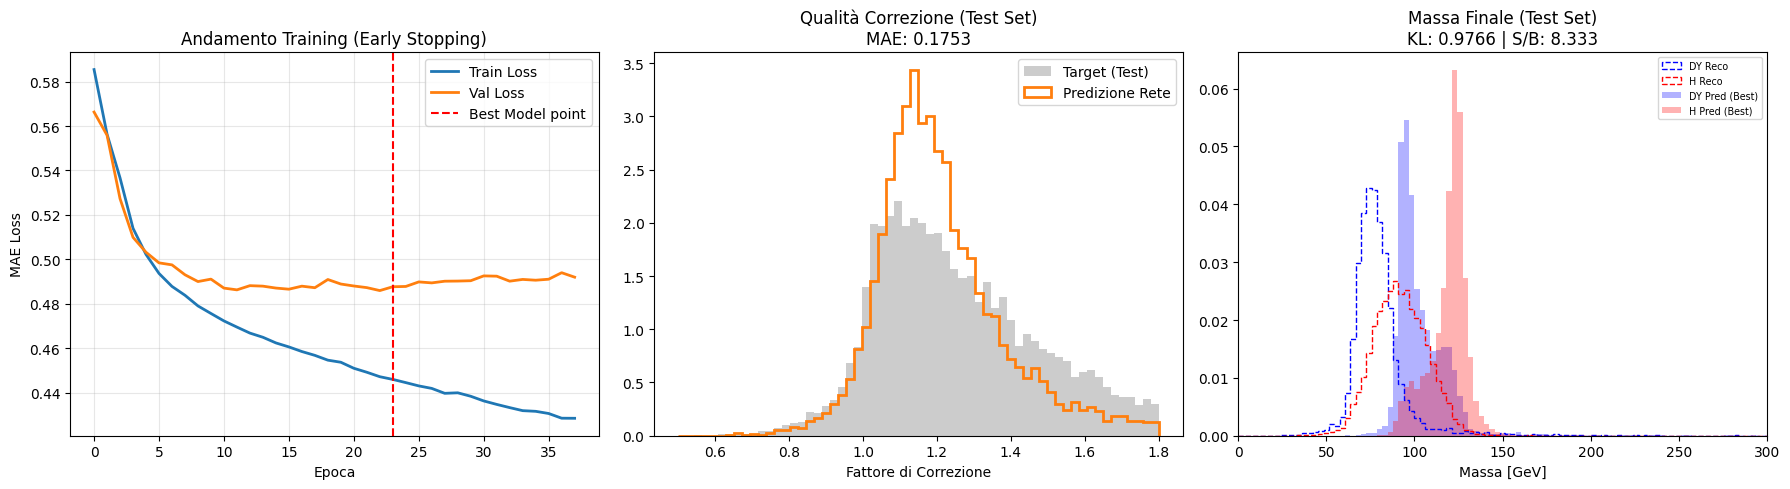

In [55]:
import matplotlib.pyplot as plt

# --- 1. PLOT DELLE LEARNING CURVES ---
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train'], label='Train Loss', color='tab:blue', lw=2)
plt.plot(history['val'], label='Val Loss', color='tab:orange', lw=2)
# Segniamo il punto di Early Stopping
plt.axvline(len(history['train'])-patience, color='red', linestyle='--', label='Best Model point')
plt.title("Andamento Training (Early Stopping)")
plt.xlabel("Epoca")
plt.ylabel("MAE Loss")
plt.legend()
plt.grid(alpha=0.3)

# --- 2. REGRESSIONE SUL TEST SET ---
plt.subplot(1, 3, 2)
plt.hist(df_test_H["tau1_corr"], bins=60, range=(0.5, 1.8), alpha=0.4, 
         label='Target (Test)', density=True, color='gray')
plt.hist(y_pred_H[:, 0], bins=60, range=(0.5, 1.8), histtype='step', 
         label='Predizione Rete', density=True, color='tab:orange', linewidth=2)
plt.title(f"Qualità Correzione (Test Set)\nMAE: {np.mean(np.abs(y_pred_H - df_test_H[y_cols].values)):.4f}")
plt.xlabel("Fattore di Correzione")
plt.legend()

# --- 3. MASSA INVARIANTE SUL TEST SET ---
plt.subplot(1, 3, 3)
bins = np.linspace(0, 300, 100)
plt.hist(df_test_DY["inv_mass_reco"], bins=bins, histtype='step', label='DY Reco', density=True, color='blue', ls='--')
plt.hist(df_test_H["inv_mass_reco"], bins=bins, histtype='step', label='H Reco', density=True, color='red', ls='--')
plt.hist(m_inv_DY_test, bins=bins, alpha=0.3, label='DY Pred (Best)', density=True, color='blue')
plt.hist(m_inv_H_test, bins=bins, alpha=0.3, label='H Pred (Best)', density=True, color='red')
# plt.axvspan(110, 140, color='green', alpha=0.1, label='Higgs Window')
plt.title(f"Massa Finale (Test Set)\nKL: {kl_final:.4f} | S/B: {s_peak/(b_peak+1e-10):.3f}")
plt.xlabel("Massa [GeV]")
plt.xlim(0, 300)
plt.legend(fontsize='x-small')

plt.tight_layout()
plt.show()

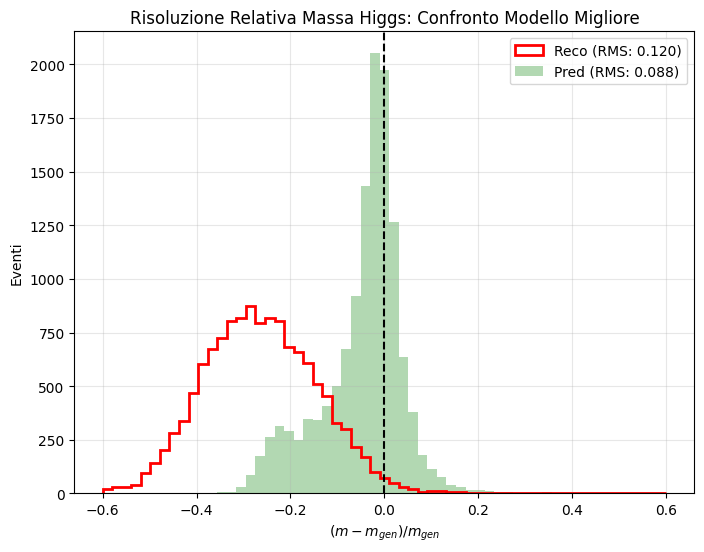

In [56]:
def plot_resolution(m_inv_pred, m_inv_reco, title):
    # Usiamo 125 GeV come target nominale per l'Higgs
    res_reco = (m_inv_reco - 125) / 125
    res_pred = (m_inv_pred - 125) / 125
    
    plt.figure(figsize=(8, 6))
    bins = np.linspace(-0.6, 0.6, 60)
    
    plt.hist(res_reco, bins=bins, histtype='step', label=f'Reco (RMS: {res_reco.std():.3f})', color='red', lw=2)
    plt.hist(res_pred, bins=bins, alpha=0.3, label=f'Pred (RMS: {res_pred.std():.3f})', color='green')
    
    plt.axvline(0, color='black', linestyle='--')
    plt.title(f"Risoluzione Relativa Massa Higgs: {title}")
    plt.xlabel("$(m - m_{gen}) / m_{gen}$")
    plt.ylabel("Eventi")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Calcoliamo la massa reco solo per il test set di Higgs
m_reco_H_test = df_test_H["inv_mass_reco"].values
plot_resolution(m_inv_H_test, m_reco_H_test, "Confronto Modello Migliore")

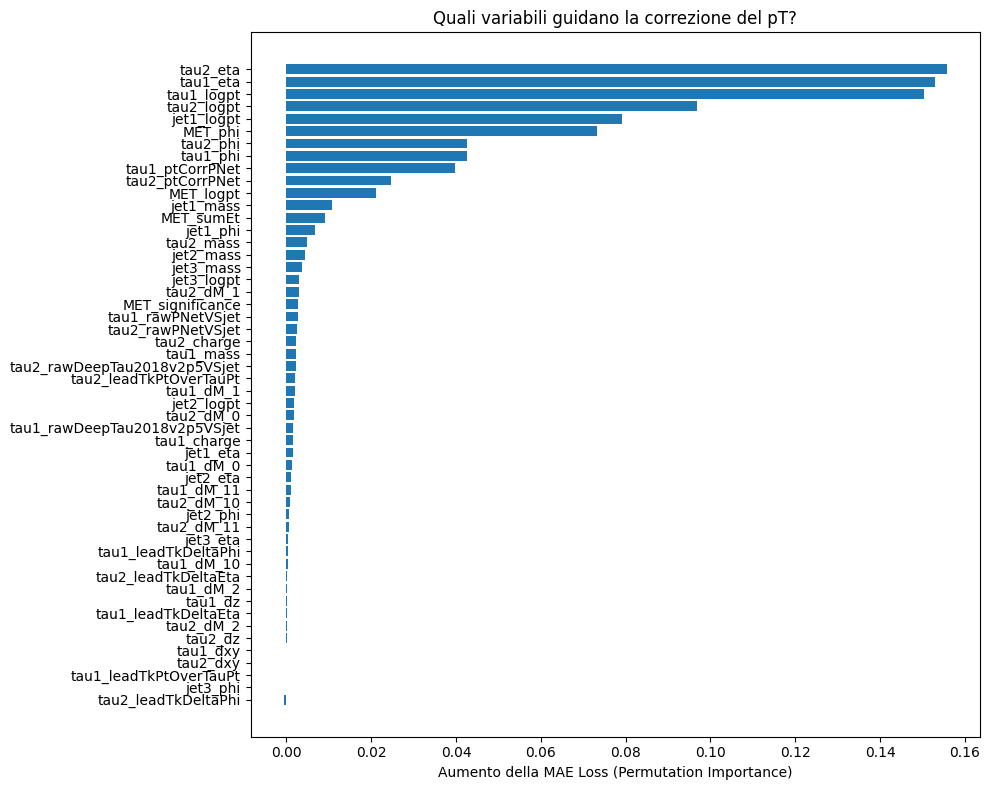

In [57]:
def calculate_feature_importance(model, df_test, cols):
    model.eval()
    X_test_tensor = scaler_X.transform(torch.tensor(df_test[cols].values, dtype=torch.float32).to(device))
    y_test_tensor = scaler_y.transform(torch.tensor(df_test[y_cols].values, dtype=torch.float32).to(device))
    
    # Loss di base
    with torch.no_grad():
        base_loss = criterion(model(X_test_tensor), y_test_tensor).item()
    
    importances = []
    for i, col in enumerate(cols):
        # Cloniamo i dati
        X_permuted = X_test_tensor.clone()
        # Mescoliamo solo la colonna i-esima
        perm = torch.randperm(X_permuted.size(0))
        X_permuted[:, i] = X_permuted[perm, i]
        
        with torch.no_grad():
            perm_loss = criterion(model(X_permuted), y_test_tensor).item()
        
        # L'importanza è l'aumento della loss
        importances.append(perm_loss - base_loss)
    
    return np.array(importances)

# Calcolo
importances = calculate_feature_importance(model, df_test, train_cols)

# Plot
plt.figure(figsize=(10, 8))
sorted_idx = np.argsort(importances)
plt.barh(np.array(train_cols)[sorted_idx], importances[sorted_idx])
plt.xlabel("Aumento della MAE Loss (Permutation Importance)")
plt.title("Quali variabili guidano la correzione del pT?")
plt.tight_layout()
plt.show()

# Cutting the dataset + Comparison

In [58]:
# --- 1. FILTRAGGIO SOFT DELLE CODE ---
# Teniamo gli eventi DY in una regione fisica ragionevole, eliminando solo gli outlier estremi
m_min, m_max = 60.0, 120.0

df_DY_soft = df_DY_event[(df_DY_event['inv_mass_reco'] > m_min) & 
                         (df_DY_event['inv_mass_reco'] < m_max)].copy()

print(f"DY Originale: {len(df_DY_event)} eventi")
print(f"DY Filtrato (60-120 GeV): {len(df_DY_soft)} eventi")
print(f"Eventi rimossi: {len(df_DY_event) - len(df_DY_soft)}")

# Uniamo con Higgs (che di solito non ha code così problematiche, ma volendo si può filtrare anche lui)
df_all_soft = pd.concat([df_DY_soft, df_H_event], ignore_index=True)

# Split 80/10/10
df_train_s, df_temp_s = train_test_split(df_all_soft, test_size=0.20, random_state=42)
df_val_s, df_test_s = train_test_split(df_temp_s, test_size=0.50, random_state=42)

# --- 2. TRAINING CON EARLY STOPPING ---
model_s = PTCorrectionNet(len(train_cols)).to(device)
optimizer_s = optim.Adam(model_s.parameters(), lr=0.001)
criterion = nn.L1Loss()

# Nuovi Scaler per il set filtrato
X_train_s = torch.tensor(df_train_s[train_cols].values, dtype=torch.float32).to(device)
y_train_s = torch.tensor(df_train_s[y_cols].values, dtype=torch.float32).to(device)
X_val_s = torch.tensor(df_val_s[train_cols].values, dtype=torch.float32).to(device)
y_val_s = torch.tensor(df_val_s[y_cols].values, dtype=torch.float32).to(device)

scaler_X_s, scaler_y_s = TorchStandardScaler(), TorchStandardScaler()
scaler_X_s.fit(X_train_s)
scaler_y_s.fit(y_train_s)

train_loader_s = DataLoader(TensorDataset(scaler_X_s.transform(X_train_s), scaler_y_s.transform(y_train_s)), batch_size=1024, shuffle=True)
val_loader_s = DataLoader(TensorDataset(scaler_X_s.transform(X_val_s), scaler_y_s.transform(y_val_s)), batch_size=1024)

best_val_s = float('inf')
history_s = {'train': [], 'val': []}
patience = 15
counter = 0

print("\nInizio Training (Soft Tail Cut)...")
for epoch in range(200):
    model_s.train()
    t_loss = 0
    for bx, by in train_loader_s:
        optimizer_s.zero_grad()
        loss = criterion(model_s(bx), by)
        loss.backward()
        optimizer_s.step()
        t_loss += loss.item()
    
    model_s.eval()
    v_loss = 0
    with torch.no_grad():
        for bx, by in val_loader_s:
            v_loss += criterion(model_s(bx), by).item()
    
    history_s['train'].append(t_loss/len(train_loader_s))
    history_s['val'].append(v_loss/len(val_loader_s))
    
    if history_s['val'][-1] < best_val_s:
        best_val_s = history_s['val'][-1]
        best_state_s = copy.deepcopy(model_s.state_dict())
        counter = 0
    else:
        counter += 1
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MAE: {history_s['train'][-1]:.4f} | Val MAE: {history_s['val'][-1]:.4f}")
    if counter >= patience:
        print(f"Fermato all'epoca {epoch}")
        break

model_s.load_state_dict(best_state_s)

DY Originale: 51425 eventi
DY Filtrato (60-120 GeV): 48708 eventi
Eventi rimossi: 2717

Inizio Training (Soft Tail Cut)...
Epoch 000 | Train MAE: 0.5920 | Val MAE: 0.5739
Epoch 010 | Train MAE: 0.4767 | Val MAE: 0.4963
Epoch 020 | Train MAE: 0.4560 | Val MAE: 0.4983
Epoch 030 | Train MAE: 0.4407 | Val MAE: 0.4982
Fermato all'epoca 30


<All keys matched successfully>

In [59]:
def evaluate_custom(model_obj, scaler_x_obj, scaler_y_obj, df):
    model_obj.eval()
    with torch.no_grad():
        X = torch.tensor(df[train_cols].values, dtype=torch.float32).to(device)
        # Predizione e inversione dello scaling
        y_p_scaled = model_obj(scaler_x_obj.transform(X))
        y_p = scaler_y_obj.inverse_transform(y_p_scaled).cpu().numpy()
    
    # Estrazione componenti per il calcolo della massa
    pt1_reco = df["tau1_pt_reco"].values
    pt2_reco = df["tau2_pt_reco"].values
    
    # Applichiamo le correzioni predette (Moltiplichiamo il pT reco per il fattore correttivo)
    pt1_pred = pt1_reco * y_p[:, 0]
    pt2_pred = pt2_reco * y_p[:, 1]
    
    # Parametri angolari e masse (invariati)
    eta1, phi1, m1 = df["tau1_eta"].values, df["tau1_phi"].values, df["tau1_mass"].values
    eta2, phi2, m2 = df["tau2_eta"].values, df["tau2_phi"].values, df["tau2_mass"].values
    
    # Calcolo quadrivettori e massa invariante
    px1, py1, pz1 = pt1_pred*np.cos(phi1), pt1_pred*np.sin(phi1), pt1_pred*np.sinh(eta1)
    e1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)
    
    px2, py2, pz2 = pt2_pred*np.cos(phi2), pt2_pred*np.sin(phi2), pt2_pred*np.sinh(eta2)
    e2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)
    
    m_inv_pred = np.sqrt(np.maximum((e1+e2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2, 0))
    
    return m_inv_pred, y_p

# --- ESECUZIONE SUI TEST SET ---
# 1. Modello Standard (Full Data)
m_inv_H_std, _ = evaluate_custom(model, scaler_X, scaler_y, df_test_H)
m_inv_DY_std, _ = evaluate_custom(model, scaler_X, scaler_y, df_test_DY)

# 2. Modello Soft-Cut (60-120 GeV)
m_inv_H_filt, _ = evaluate_custom(model_s, scaler_X_s, scaler_y_s, df_test_H)
m_inv_DY_filt, _ = evaluate_custom(model_s, scaler_X_s, scaler_y_s, df_test_DY)

print("Valutazione completata.")

Valutazione completata.


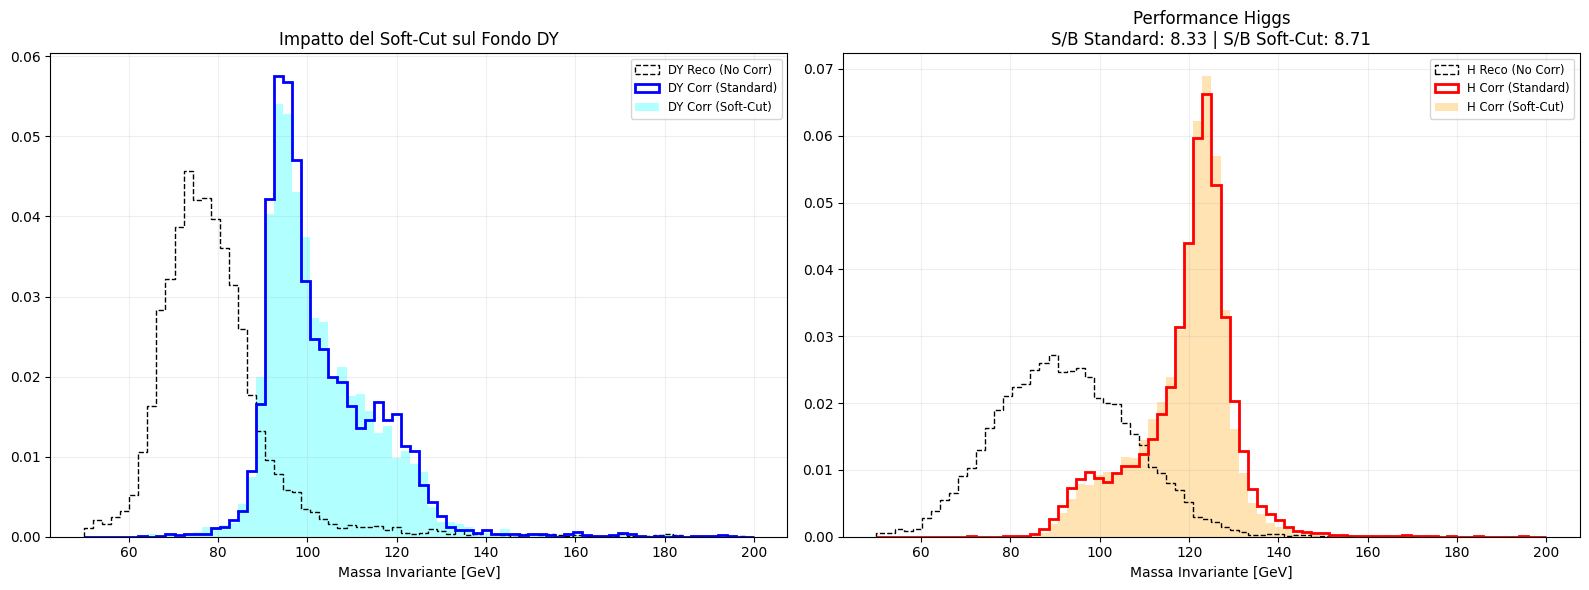

In [60]:
import matplotlib.pyplot as plt

def get_sb(m_h, m_dy):
    s = np.sum((m_h > 110) & (m_h < 140))
    b = np.sum((m_dy > 110) & (m_dy < 140))
    return s / (b + 1e-10)

sb_std = get_sb(m_inv_H_std, m_inv_DY_std)
sb_filt = get_sb(m_inv_H_filt, m_inv_DY_filt)

plt.figure(figsize=(16, 6))

# --- PLOT A: Drell-Yan (Stabilità delle code) ---
plt.subplot(1, 2, 1)
bins_m = np.linspace(50, 200, 75)

plt.hist(df_test_DY["inv_mass_reco"], bins=bins_m, histtype='step', label='DY Reco (No Corr)', color='black', ls='--', density=True)
plt.hist(m_inv_DY_std, bins=bins_m, histtype='step', label='DY Corr (Standard)', color='blue', lw=2, density=True)
plt.hist(m_inv_DY_filt, bins=bins_m, alpha=0.3, label='DY Corr (Soft-Cut)', color='cyan', density=True)

plt.title("Impatto del Soft-Cut sul Fondo DY")
plt.xlabel("Massa Invariante [GeV]")
plt.legend(fontsize='small')
plt.grid(alpha=0.2)

# --- PLOT B: Higgs (Risoluzione del Segnale) ---
plt.subplot(1, 2, 2)
plt.hist(df_test_H["inv_mass_reco"], bins=bins_m, histtype='step', label='H Reco (No Corr)', color='black', ls='--', density=True)
plt.hist(m_inv_H_std, bins=bins_m, histtype='step', label='H Corr (Standard)', color='red', lw=2, density=True)
plt.hist(m_inv_H_filt, bins=bins_m, alpha=0.3, label='H Corr (Soft-Cut)', color='orange', density=True)

plt.title(f"Performance Higgs\nS/B Standard: {sb_std:.2f} | S/B Soft-Cut: {sb_filt:.2f}")
plt.xlabel("Massa Invariante [GeV]")
plt.legend(fontsize='small')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [61]:
# Confronto tra le due distribuzioni (pre-post cut):
from scipy.stats import ks_2samp

# 1. Calcolo Risoluzione (Larghezza del picco)
res_std = m_inv_H_std.std()
res_filt = m_inv_H_filt.std()

# 2. Calcolo Bias (Quanto siamo vicini a 125 GeV)
bias_std = np.mean(m_inv_H_std) - 125
bias_filt = np.mean(m_inv_H_filt) - 125

# 3. Test di Kolmogorov-Smirnov (per il fondo DY)
# (ci dice matematicamente se due distribuzioni sono estratte dalla stessa popolazione 
#  o se c'è una differenza sistematica)
ks_stat, p_value = ks_2samp(m_inv_DY_std, m_inv_DY_filt)

print("--- CONFRONTO ANALITICO ---")
print(f"Risoluzione Higgs (Std): {res_std:.4f} GeV")
print(f"Risoluzione Higgs (Soft-Cut): {res_filt:.4f} GeV")
print(f"Miglioramento Risoluzione: {((res_std - res_filt) / res_std)*100:.2f}%")
print("-" * 30)
print(f"Bias Higgs (Std): {bias_std:.4f} GeV")
print(f"Bias Higgs (Soft-Cut): {bias_filt:.4f} GeV")
print("-" * 30)
print(f"KS Test p-value (DY): {p_value:.4f}")
if p_value > 0.05:
    print("Esito: Le distribuzioni del fondo sono statisticamente indistinguibili.")
else:
    print("Esito: Il taglio delle code ha cambiato significativamente la forma del fondo.")

--- CONFRONTO ANALITICO ---
Risoluzione Higgs (Std): 10.9743 GeV
Risoluzione Higgs (Soft-Cut): 10.1109 GeV
Miglioramento Risoluzione: 7.87%
------------------------------
Bias Higgs (Std): -5.7881 GeV
Bias Higgs (Soft-Cut): -6.1101 GeV
------------------------------
KS Test p-value (DY): 0.0228
Esito: Il taglio delle code ha cambiato significativamente la forma del fondo.


# Modelli Balanced e Unbalanced

In [62]:
# --- A: Dataset Sbilanciato (Originale) ---
# Uso tutti gli eventi disponibili
df_unbalanced = pd.concat([df_DY_event, df_H_event], ignore_index=True)
print(f"Sbilanciato - DY: {len(df_DY_event)}, Higgs: {len(df_H_event)}")

# --- B: Dataset Bilanciato (Downsampling) ---
# Se l'Higgs ne ha di più, campiono un numero di eventi Higgs pari a quelli del DY
n_samples = min(len(df_DY_event), len(df_H_event))

df_DY_bal = df_DY_event.sample(n=n_samples, random_state=42)
df_H_bal = df_H_event.sample(n=n_samples, random_state=42)

df_balanced = pd.concat([df_DY_bal, df_H_bal], ignore_index=True)
print(f"Bilanciato - DY: {n_samples}, Higgs: {n_samples}")

Sbilanciato - DY: 51425, Higgs: 128034
Bilanciato - DY: 51425, Higgs: 51425


In [63]:
def train_and_get_model(df_train_full, train_cols, y_cols, title):
    # Split
    df_t, df_v = train_test_split(df_train_full, test_size=0.2, random_state=42)
    
    # Tensori e Scaling
    X_t = torch.tensor(df_t[train_cols].values, dtype=torch.float32).to(device)
    y_t = torch.tensor(df_t[y_cols].values, dtype=torch.float32).to(device)
    X_v = torch.tensor(df_v[train_cols].values, dtype=torch.float32).to(device)
    y_v = torch.tensor(df_v[y_cols].values, dtype=torch.float32).to(device)
    
    sc_X, sc_y = TorchStandardScaler(), TorchStandardScaler()
    sc_X.fit(X_t); sc_y.fit(y_t)
    
    loader = DataLoader(TensorDataset(sc_X.transform(X_t), sc_y.transform(y_t)), batch_size=1024, shuffle=True)
    v_loader = DataLoader(TensorDataset(sc_X.transform(X_v), sc_y.transform(y_v)), batch_size=1024)
    
    # Modello
    m = PTCorrectionNet(len(train_cols)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    crit = nn.L1Loss()
    
    best_v = float('inf')
    best_st = None
    for e in range(100):
        m.train()
        for bx, by in loader:
            opt.zero_grad(); crit(m(bx), by).backward(); opt.step()
        m.eval()
        curr_v = 0
        with torch.no_grad():
            for bx, by in v_loader: curr_v += crit(m(bx), by).item()
        curr_v /= len(v_loader)
        if curr_v < best_v:
            best_v = curr_v
            best_st = copy.deepcopy(m.state_dict())
            
    m.load_state_dict(best_st)
    print(f"Finita {title} | Best Val Loss: {best_v:.4f}")
    return m, sc_X, sc_y

# Esecuzione
model_unbal, sc_X_u, sc_y_u = train_and_get_model(df_unbalanced, train_cols, y_cols, "Sbilanciato")
model_bal, sc_X_b, sc_y_b = train_and_get_model(df_balanced, train_cols, y_cols, "Bilanciato")

Finita Sbilanciato | Best Val Loss: 0.4872
Finita Bilanciato | Best Val Loss: 0.5113


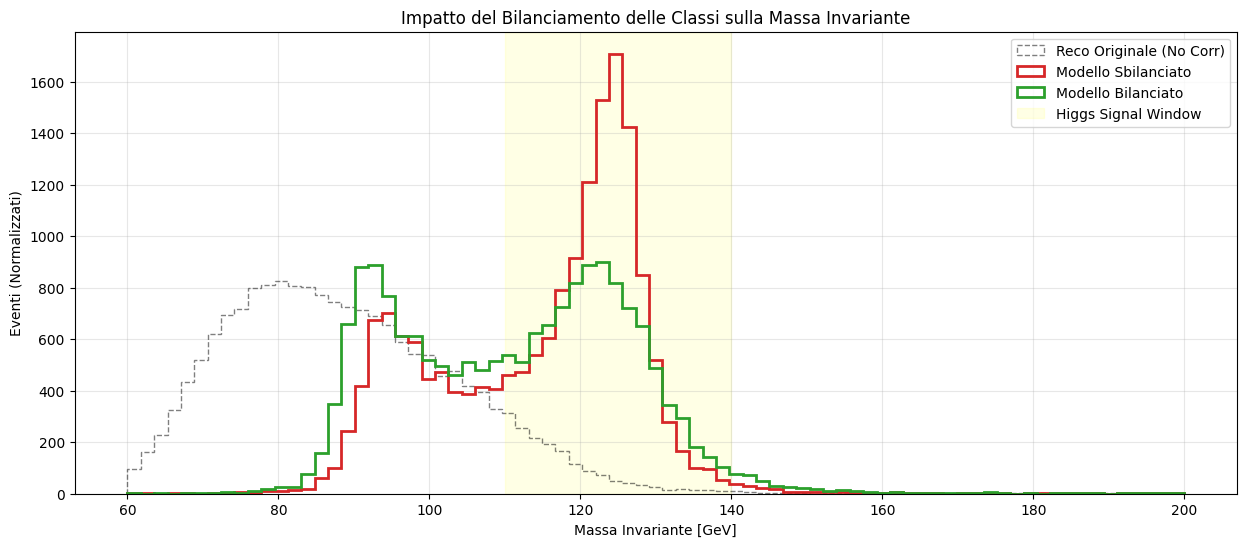

--- RISULTATI NUMERICI ---
MODELLO SBILANCIATO: S/B = 8.846 | Risoluzione H (RMS) = 10.41 GeV | Fondo in SR = 1181
MODELLO BILANCIATO:   S/B = 17.291 | Risoluzione H (RMS) = 12.96 GeV | Fondo in SR = 509
------------------------------
VANTAGGIO: Il bilanciamento ha migliorato S/B del 95.5%


In [65]:
# --- 1. PREPARAZIONE TEST SET COMUNE ---
# Unisco campioni di test che il modello non ha mai visto
df_test_common = pd.concat([
    df_DY_event.sample(frac=0.1, random_state=42), 
    df_H_event.sample(frac=0.1, random_state=42)
], ignore_index=True)

# --- 2. VALUTAZIONE ---
m_inv_unbal, _ = evaluate_custom(model_unbal, sc_X_u, sc_y_u, df_test_common)
m_inv_bal, _ = evaluate_custom(model_bal, sc_X_b, sc_y_b, df_test_common)

# --- 3. PLOT DI CONFRONTO ---
plt.figure(figsize=(15, 6))

bins = np.linspace(60, 200, 80)
plt.hist(df_test_common["inv_mass_reco"], bins=bins, histtype='step', label='Reco Originale (No Corr)', color='black', ls='--', alpha=0.5)
plt.hist(m_inv_unbal, bins=bins, histtype='step', label='Modello Sbilanciato', color='tab:red', lw=2)
plt.hist(m_inv_bal, bins=bins, histtype='step', label='Modello Bilanciato', color='tab:green', lw=2)

plt.axvspan(110, 140, color='yellow', alpha=0.1, label='Higgs Signal Window')
plt.title("Impatto del Bilanciamento delle Classi sulla Massa Invariante")
plt.xlabel("Massa Invariante [GeV]")
plt.ylabel("Eventi (Normalizzati)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 4. CALCOLO S/B E RISOLUZIONE ---
def get_metrics(m_inv, df):
    # Maschere basate sulla colonna 'class'
    is_h = (df["class"] == 1)
    is_dy = (df["class"] == 0)
    
    # Segnale e Fondo nella finestra 110-140
    s = np.sum((m_inv[is_h] > 110) & (m_inv[is_h] < 140))
    b = np.sum((m_inv[is_dy] > 110) & (m_inv[is_dy] < 140))
    sb_ratio = s / (b + 1e-10)
    
    # Risoluzione Higgs (RMS del picco)
    h_res = m_inv[is_h].std()
    
    return sb_ratio, h_res, s, b

sb_u, res_u, s_u, b_u = get_metrics(m_inv_unbal, df_test_common)
sb_b, res_b, s_b, b_b = get_metrics(m_inv_bal, df_test_common)

print("--- RISULTATI NUMERICI ---")
print(f"MODELLO SBILANCIATO: S/B = {sb_u:.3f} | Risoluzione H (RMS) = {res_u:.2f} GeV | Fondo in SR = {b_u}")
print(f"MODELLO BILANCIATO:   S/B = {sb_b:.3f} | Risoluzione H (RMS) = {res_b:.2f} GeV | Fondo in SR = {b_b}")
print("-" * 30)
if sb_b > sb_u:
    print(f"VANTAGGIO: Il bilanciamento ha migliorato S/B del {((sb_b/sb_u)-1)*100:.1f}%")
else:
    print("VANTAGGIO: Lo sbilanciamento (più dati) sembra favorire la statistica totale.")

In [67]:
# -> Il modello sbilanciato è più "preciso" sul segnale (picco più stretto)
# -> Nel modello bilanciato il fondo nel segnale (SR) è crollato da 1181 a 509

# Flat Samples

In [68]:
# --------- Apro i samples flat  ------------
VBF = np.load("VBFtoXto2Tau_M-30to300.npz")

print(VBF.files)

['x_taus', 'x_tauprod', 'x_met', 'x_jets', 'x_neutrinos', 'x_gen', 'm_vis', 'm_vis_ptcorr', 'm_gen', 'm_gen_pt_vis_angles', 'm_vis_ptcorr_plus_nu', 'm_tauprod_nu', 'm_vis_nu_vis', 'm_fastmtt']


In [69]:
# check :
print("x_taus:", VBF["x_taus"].shape)
print("x_taus_gen", VBF["x_gen"].shape)
print("x_met :", VBF["x_met"].shape)
print("x_jets:", VBF["x_jets"].shape)
print("m_gen :", VBF["m_gen"].shape)

x_taus: (632014, 2, 18)
x_taus_gen (632014, 2, 4)
x_met : (632014, 1, 8)
x_jets: (632014, 3, 4)
m_gen : (632014,)


In [70]:
taus = VBF["x_taus"]        # shape (N, 2, 18)
# tauprod = VBF["x_tauprod"]  # shape (N, 10, 10)
tau_gen = VBF["x_gen"]       # shape (N, 2,  4)
met = VBF["x_met"]          # shape (N, 1, 8)
jets = VBF["x_jets"]        # shape (N, 3, 4)

m_vis_ptcorr = VBF["m_vis_ptcorr"]   # (N,)    --> La uso come m_reco
m_target = VBF["m_gen"]              # (N,)
m_vis = VBF["m_vis"]                 # (N,)
m_fastmtt = VBF["m_fastmtt"]         # (N,)


tau_features = [
    "logpt", "eta", "phi", "mass", "dxy", "dz",
    "ptCorrPNet", "rawPNetVSjet", "rawDeepTau2018v2p5VSjet",
    "charge",
    "dM_0", "dM_1", "dM_2", "dM_10", "dM_11",
    "leadTkDeltaEta", "leadTkDeltaPhi", "leadTkPtOverTauPt"
]

gen_tau_features = ["pt", "eta", "phi", "mass"]  # x_gen


import pandas as pd

N = taus.shape[0]

df = {}

# ---------- TAU 1 & TAU 2 ----------
for itau in [0, 1]:
    prefix = f"tau{itau+1}_"
    for i, feat in enumerate(tau_features):
        df[prefix + feat] = taus[:, itau, i]

# ---------- TAU GEN (TAU 1 & TAU 2) ----------
for itau in [0, 1]:
    prefix = f"gen_tau{itau+1}_"
    for i, feat in enumerate(gen_tau_features):
        df[prefix + feat] = tau_gen[:, itau, i]

# ---------- MET ----------
met_features = [
    "MET_logpt", "MET_phi", "MET_covXX", "MET_covXY",
    "MET_covYY", "MET_significance", "MET_sumEt", "MET_sumPtUnclustered"
]

for i, feat in enumerate(met_features):
    df[feat] = met[:, 0, i]

# ---------- JETS (3 jets) ----------
jet_features = ["logpt", "eta", "phi", "mass"]

for j in range(3):
    for i, feat in enumerate(jet_features):
        df[f"jet{j+1}_{feat}"] = jets[:, j, i]

# ---------- MASSE ----------
df["m_vis"]         = m_vis
df["m_vis_ptcorr"]  = m_vis_ptcorr
df["m_fastmtt"]     = m_fastmtt
df["m_gen"]         = m_target


df_flat = pd.DataFrame(df)

print(df_flat.shape)
df_flat.head()

(632014, 68)


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,m_vis,m_vis_ptcorr,m_fastmtt,m_gen
0,4.200094,1.643799,2.515137,2.949219,0.634277,5.184814,1.001953,0.999512,-1.000000,-1.0,...,-1.327881,5.281250,2.880777,1.763184,-0.800903,3.589844,24.438859,27.647144,33.020302,47.239086
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,1.614990,10.671875,2.833213,-0.185181,2.087402,3.179688,85.437739,93.784651,109.942673,106.047752
2,3.746890,-0.771606,2.914062,1.334961,0.001616,-0.001660,0.996582,0.883789,0.977051,1.0,...,0.796753,6.765625,3.711283,1.373779,2.641602,7.281250,61.325864,60.001639,83.316399,77.556129
3,3.882379,-1.166748,-0.862671,0.836914,-0.000545,0.000682,0.957031,0.780762,0.909668,1.0,...,2.308594,4.167969,3.327730,-2.611816,2.785645,4.589844,109.263026,97.097534,148.204529,102.891235
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,-2.422363,6.937500,3.800393,1.051758,2.386719,6.730469,104.564076,127.417169,143.905762,133.224426


In [71]:
df_flat["gen_tau1_logpt"] = np.log(np.clip(tau_gen[:, 0, 0], 1e-6, None))
df_flat["gen_tau2_logpt"] = np.log(np.clip(tau_gen[:, 1, 0], 1e-6, None))

In [72]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df_flat["tau1_logpt"] > log_pt_min) & (df_flat["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_flat))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel_flat = df_flat[mask_pt].copy()
df_sel_flat

Eventi totali: 632014
Eventi che passano pT>30 GeV (in log): 394047


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,2.833213,-0.185181,2.087402,3.179688,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,3.800393,1.051758,2.386719,6.730469,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,3.796191,2.697754,1.850342,9.632812,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,4.121068,-1.615723,0.101578,10.609375,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,3.065142,2.163574,1.464600,3.421875,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,4.666971,0.828857,-2.566895,12.578125,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,2.828607,-3.270996,0.870728,3.333984,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,2.790014,3.534668,-2.531250,1.416016,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,3.187772,-4.248047,0.012825,2.980469,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337


In [73]:
df_sel_flat["tau1_ptreco"] = np.exp(df_sel_flat["tau1_logpt"])
df_sel_flat["tau2_ptreco"] = np.exp(df_sel_flat["tau2_logpt"])

df_sel_flat["tau1_pt_reco_corrPNet"] = df_sel_flat["tau1_ptreco"] * df_sel_flat["tau1_ptCorrPNet"]
df_sel_flat["tau2_pt_reco_corrPNet"] = df_sel_flat["tau2_ptreco"] * df_sel_flat["tau2_ptCorrPNet"]
df_sel_flat

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


In [74]:
# tau ID

df_sel_flat_valid = df_sel_flat[
    (df_sel_flat["tau1_rawPNetVSjet"] != -1) &
    (df_sel_flat["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_flat_valid))

# Soglia al working point 90% :
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90

vals_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"].values
thresholds_tau1 = np.sort(np.unique(vals_tau1))

vals_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"].values
thresholds_tau2 = np.sort(np.unique(vals_tau2))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

# Applico le soglie event - level : 
mask_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_event  = mask_tau1 & mask_tau2

df_sel_tauID = df_sel_flat_valid[mask_event].copy()

# efficienza event-level 
eff_event = mask_event.mean() if len(df_sel_flat_valid) > 0 else float("nan")

print("Efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_event:.4f}")

df_flat_event = df_sel_tauID.copy()
df_flat_event

DY valid events = 391777
Efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8129


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


Before cut: 318494
After cut: 124121


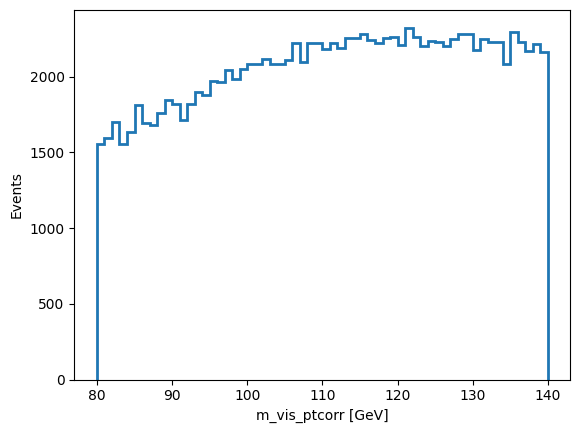

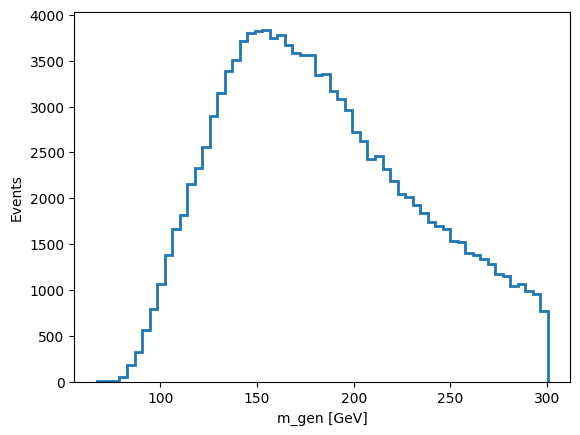

In [75]:
# taglio in massa -> su m_vis_ptcorr
print("Before cut:", len(df_flat_event))

df_flat_cut = df_flat_event[
    (df_flat_event["m_vis_ptcorr"] >= 80.0) &
    (df_flat_event["m_vis_ptcorr"] <= 140.0)
].copy()

print("After cut:", len(df_flat_cut))

# just checking 
import matplotlib.pyplot as plt

plt.hist(df_flat_cut["m_vis_ptcorr"], bins=60, histtype = 'step', linewidth = 2, density = False)   # -> Me lo aspetto quasi piatto 
plt.xlabel("m_vis_ptcorr [GeV]")
plt.ylabel("Events")
plt.show()


plt.hist(df_flat_cut["m_gen"], bins=60, histtype = 'step', linewidth = 2, density = False)
plt.xlabel("m_gen [GeV]")
plt.ylabel("Events")
plt.show()

In [76]:
# Preparazione per training 

eps = 1e-8

# Li rinomino coerentemente con il precedente modello :
df_flat_cut["tau1_pt_gen"] = df_flat_cut["gen_tau1_pt"]
df_flat_cut["tau2_pt_gen"] = df_flat_cut["gen_tau2_pt"]

# --- target: fattore di correzione ---
df_flat_cut["tau1_corr"] = df_flat_cut["tau1_pt_gen"] / np.clip(df_flat_cut["tau1_pt_reco_corrPNet"], eps, None)
df_flat_cut["tau2_corr"] = df_flat_cut["tau2_pt_gen"] / np.clip(df_flat_cut["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]

In [77]:
# Pre-training:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy
import numpy as np

# --- 1. DEFINIZIONE FEATURE (train_cols) ---
# train_cols esiste già, uso lo stesso

y_cols = ['tau1_corr', 'tau2_corr']

# --- 2. SPLIT DEL DATAFRAME FLAT ---
df_train_flat, df_val_flat = train_test_split(df_flat_cut, test_size=0.2, random_state=42)

# --- 3. SCALING SPECIFICO PER FLAT ---
# Uso nomi univoci per non sovrascrivere gli scaler dei campioni fisici dopo
scaler_X_flat = TorchStandardScaler()
scaler_y_flat = TorchStandardScaler()

X_train_f_raw = torch.tensor(df_train_flat[train_cols].values, dtype=torch.float32).to(device)
y_train_f_raw = torch.tensor(df_train_flat[y_cols].values, dtype=torch.float32).to(device)
X_val_f_raw = torch.tensor(df_val_flat[train_cols].values, dtype=torch.float32).to(device)
y_val_f_raw = torch.tensor(df_val_flat[y_cols].values, dtype=torch.float32).to(device)

scaler_X_flat.fit(X_train_f_raw)
scaler_y_flat.fit(y_train_f_raw)

# DataLoader per la fase Flat
train_loader_flat = DataLoader(
    TensorDataset(scaler_X_flat.transform(X_train_f_raw), scaler_y_flat.transform(y_train_f_raw)), 
    batch_size=1024, shuffle=True
)
val_loader_flat = DataLoader(
    TensorDataset(scaler_X_flat.transform(X_val_f_raw), scaler_y_flat.transform(y_val_f_raw)), 
    batch_size=1024
)

# --- 4. ARCHITETTURA MODELLO ---
# Definisco il modello che poi passerà al fine-tuning
model_flat = nn.Sequential(
    nn.Linear(len(train_cols), 256), nn.BatchNorm1d(256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 2)
).to(device)

# --- 5. TRAINING FASE 1 (Pre-training) ---
optimizer_flat = optim.Adam(model_flat.parameters(), lr=0.001)
criterion = nn.L1Loss()

print("Inizio Pre-training su Flat Samples")
best_flat_state = None
best_v_loss = float('inf')
patience_flat = 15
counter = 0

for epoch in range(200):
    model_flat.train()
    for bx, by in train_loader_flat:
        optimizer_flat.zero_grad()
        criterion(model_flat(bx), by).backward()
        optimizer_flat.step()
    
    model_flat.eval()
    v_loss = 0
    with torch.no_grad():
        for bx, by in val_loader_flat:
            v_loss += criterion(model_flat(bx), by).item()
    v_loss /= len(val_loader_flat)
    
    if v_loss < best_v_loss:
        best_v_loss = v_loss
        best_flat_state = copy.deepcopy(model_flat.state_dict())
        counter = 0
    else:
        counter += 1
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Val Loss: {v_loss:.6f}")
    
    if counter >= patience_flat:
        print(f"Early stopping alla epoca {epoch}")
        break

# Carichiamo i pesi migliori prima di finire
model_flat.load_state_dict(best_flat_state)
print("Pre-training completato con successo.")

Inizio Pre-training su Flat Samples
Epoch 000 | Val Loss: 0.586125
Epoch 010 | Val Loss: 0.476672
Epoch 020 | Val Loss: 0.473461
Epoch 030 | Val Loss: 0.474013
Early stopping alla epoca 38
Pre-training completato con successo.


In [78]:
# --- 1. PREPARAZIONE DATASET FISICO BILANCIATO ---
# Campionamento bilanciato (1:1) per evitare il bias dell'Higgs
n_samples = min(len(df_DY_event), len(df_H_event))
df_DY_bal = df_DY_event.sample(n=n_samples, random_state=42)
df_H_bal = df_H_event.sample(n=n_samples, random_state=42)
df_phys_bal = pd.concat([df_DY_bal, df_H_bal], ignore_index=True)

# Split fisico
df_train_ph, df_val_ph = train_test_split(df_phys_bal, test_size=0.2, random_state=42)

# --- 2. SCALING FISICO ---
# Creo nuovi scaler perché la distribuzione fisica (piccata) è diversa dalla flat
scaler_X_ph = TorchStandardScaler()
scaler_y_ph = TorchStandardScaler()

X_train_ph_raw = torch.tensor(df_train_ph[train_cols].values, dtype=torch.float32).to(device)
y_train_ph_raw = torch.tensor(df_train_ph[y_cols].values, dtype=torch.float32).to(device)
X_val_ph_raw = torch.tensor(df_val_ph[train_cols].values, dtype=torch.float32).to(device)
y_val_ph_raw = torch.tensor(df_val_ph[y_cols].values, dtype=torch.float32).to(device)

scaler_X_ph.fit(X_train_ph_raw)
scaler_y_ph.fit(y_train_ph_raw)

train_loader_ph = DataLoader(
    TensorDataset(scaler_X_ph.transform(X_train_ph_raw), scaler_y_ph.transform(y_train_ph_raw)), 
    batch_size=1024, shuffle=True
)
val_loader_ph = DataLoader(
    TensorDataset(scaler_X_ph.transform(X_val_ph_raw), scaler_y_ph.transform(y_val_ph_raw)), 
    batch_size=1024
)

# --- 3. PREPARAZIONE MODELLO (Eredità dai Flat) ---
# Uso model_flat che ha già caricato best_flat_state
model_final = model_flat 

# Optimizer con Learning Rate ridotto (0.0001 invece di 0.001)
optimizer_ft = optim.Adam(model_final.parameters(), lr=0.0001)

# --- 4. TRAINING FASE 2 ---
print("Inizio Fine-tuning su DY + Higgs (Bilanciato)")
best_ph_state = None
best_ph_loss = float('inf')
patience_ft = 15
counter = 0

for epoch in range(100):
    model_final.train()
    for bx, by in train_loader_ph:
        optimizer_ft.zero_grad()
        criterion(model_final(bx), by).backward()
        optimizer_ft.step()
    
    model_final.eval()
    v_loss = 0
    with torch.no_grad():
        for bx, by in val_loader_ph:
            v_loss += criterion(model_final(bx), by).item()
    v_loss /= len(val_loader_ph)
    
    if v_loss < best_ph_loss:
        best_ph_loss = v_loss
        best_ph_state = copy.deepcopy(model_final.state_dict())
        counter = 0
    else:
        counter += 1
    
    if epoch % 5 == 0:
        print(f"FT Epoch {epoch:02d} | Val Loss: {v_loss:.6f}")
    
    if counter >= patience_ft:
        print(f"Fine-tuning terminato per Early Stopping alla epoca {epoch}")
        break

model_final.load_state_dict(best_ph_state)
print("Fine-tuning completato.")

Inizio Fine-tuning su DY + Higgs (Bilanciato)
FT Epoch 00 | Val Loss: 0.593411
FT Epoch 05 | Val Loss: 0.536034
FT Epoch 10 | Val Loss: 0.527935
FT Epoch 15 | Val Loss: 0.524644
FT Epoch 20 | Val Loss: 0.522695
FT Epoch 25 | Val Loss: 0.521140
FT Epoch 30 | Val Loss: 0.519992
FT Epoch 35 | Val Loss: 0.519794
FT Epoch 40 | Val Loss: 0.519405
FT Epoch 45 | Val Loss: 0.518811
FT Epoch 50 | Val Loss: 0.518530
FT Epoch 55 | Val Loss: 0.519408
FT Epoch 60 | Val Loss: 0.518186
FT Epoch 65 | Val Loss: 0.517938
FT Epoch 70 | Val Loss: 0.518575
FT Epoch 75 | Val Loss: 0.518690
FT Epoch 80 | Val Loss: 0.518346
Fine-tuning terminato per Early Stopping alla epoca 80
Fine-tuning completato.


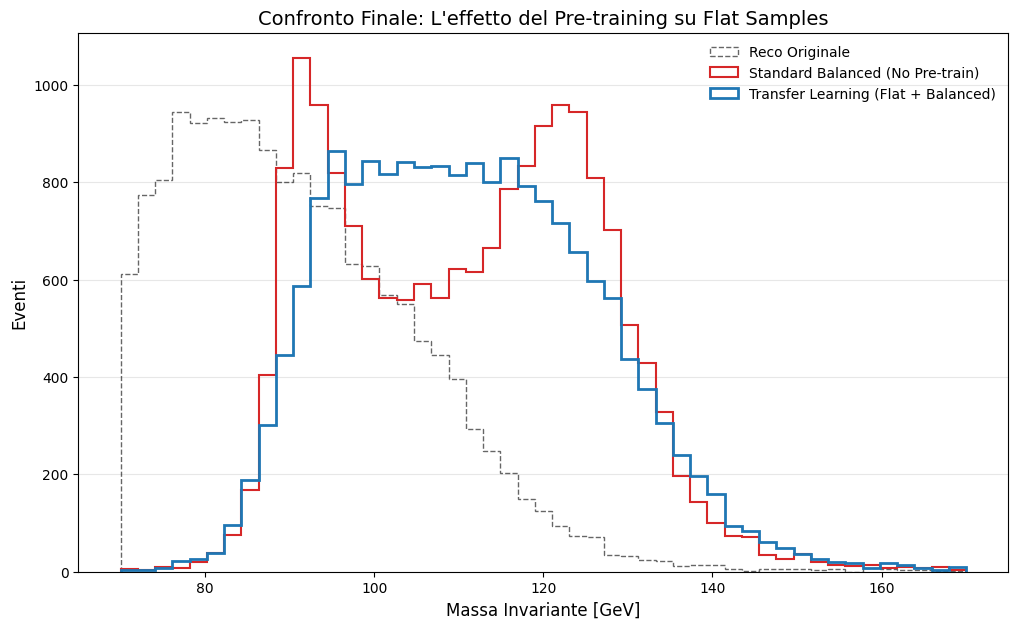

Risoluzione Higgs (Standard): 13.42 GeV
Risoluzione Higgs (Transfer Learning): 13.29 GeV
Miglioramento relativo: 1.0%


In [79]:
# --- 1. PREPARAZIONE TEST SET INDIPENDENTE ---
# Uso un campione che non è mai entrato in nessuna fase di training
df_test_final = pd.concat([
    df_DY_event.sample(frac=0.1, random_state=99), 
    df_H_event.sample(frac=0.1, random_state=99)
], ignore_index=True)

# --- 2. VALUTAZIONE ---
# Massa con modello standard bilanciato (usa lo scaler del training bilanciato di prima)
m_inv_bal_std, _ = evaluate_custom(model_bal, sc_X_b, sc_y_b, df_test_final)

# Massa con nuovo modello Transfer Learning (usa lo scaler fisico del fine-tuning)
m_inv_tl, _ = evaluate_custom(model_final, scaler_X_ph, scaler_y_ph, df_test_final)

# --- 3. PLOT DI CONFRONTO ---
plt.figure(figsize=(12, 7))

bins = np.linspace(70, 170, 50)

plt.hist(df_test_final["inv_mass_reco"], bins=bins, histtype='step', 
         label='Reco Originale', color='black', ls='--', alpha=0.6)

plt.hist(m_inv_bal_std, bins=bins, histtype='step', 
         label='Standard Balanced (No Pre-train)', color='tab:red', lw=1.5)

plt.hist(m_inv_tl, bins=bins, histtype='step', 
         label='Transfer Learning (Flat + Balanced)', color='tab:blue', lw=2)

# plt.axvspan(110, 140, color='yellow', alpha=0.1, label='Higgs Region')
plt.title("Confronto Finale: L'effetto del Pre-training su Flat Samples", fontsize=14)
plt.xlabel("Massa Invariante [GeV]", fontsize=12)
plt.ylabel("Eventi", fontsize=12)
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.3)

plt.show()

# --- 4. ANALISI DELLA RISOLUZIONE ---
is_h = (df_test_final["class"] == 1)
res_std = m_inv_bal_std[is_h].std()
res_tl = m_inv_tl[is_h].std()

print(f"Risoluzione Higgs (Standard): {res_std:.2f} GeV")
print(f"Risoluzione Higgs (Transfer Learning): {res_tl:.2f} GeV")
print(f"Miglioramento relativo: {((res_std - res_tl) / res_std)*100:.1f}%")

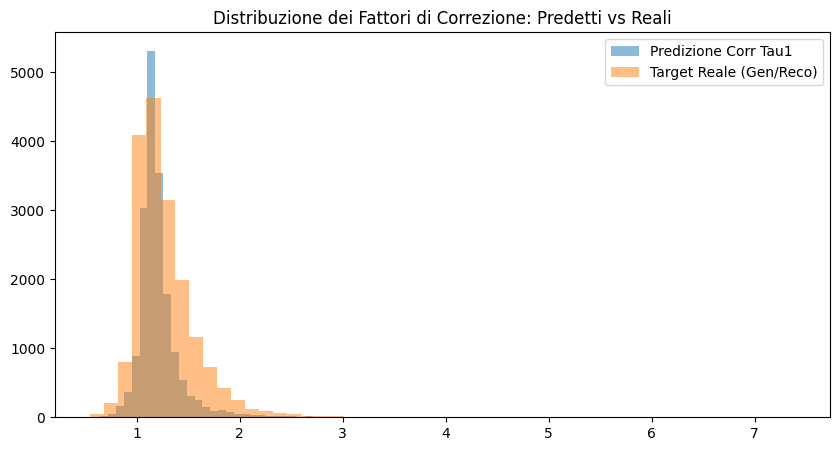

In [81]:
# Prendo un po' di dati dal test set
X_test_tensor = scaler_X_ph.transform(torch.tensor(df_test_final[train_cols].values, dtype=torch.float32).to(device))

model_final.eval()
with torch.no_grad():
    preds = model_final(X_test_tensor).cpu().numpy()
    # Torniamo ai valori reali (non scalati) se avevi scalato anche la Y
    preds_real = scaler_y_ph.inverse_transform(torch.tensor(preds)).numpy()

plt.figure(figsize=(10, 5))
plt.hist(preds_real[:, 0], bins=50, alpha=0.5, label='Predizione Corr Tau1')
plt.hist(df_test_final['tau1_corr'].values, bins=50, alpha=0.5, label='Target Reale (Gen/Reco)')
plt.title("Distribuzione dei Fattori di Correzione: Predetti vs Reali")
plt.legend()
plt.show()